# Lepsze procesowanie dla większych zbiorów

In [1]:
from google.colab import drive
import pandas as pd
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import json
import csv
import os

files_config = {
    '5core_ratings': '/content/drive/My Drive/INŻYNIERKA/All_Beauty_5_ratings.csv',
    'full_reviews': '/content/drive/My Drive/INŻYNIERKA/All_Beauty_full_reviews.jsonl',
    'metadata': '/content/drive/My Drive/INŻYNIERKA/meta_All_Beauty_full.jsonl',

    'out_train': '/content/drive/My Drive/INŻYNIERKA/neo4j_train_reviews.csv',
    'out_test': '/content/drive/My Drive/INŻYNIERKA/neo4j_test_reviews.csv',
    'out_prod': '/content/drive/My Drive/INŻYNIERKA/neo4j_products.csv'
}

In [3]:
print(f"Analyzing 5-core interactions from {files_config['5core_ratings']} ---")
df_5core = pd.read_csv(files_config['5core_ratings'])

Analyzing 5-core interactions from /content/drive/My Drive/INŻYNIERKA/All_Beauty_5_ratings.csv ---


All_beauty kategoria: w tym pliku mamy 2535 ratingów od 253 użytkowników dla 356 przedmiotów.

In [4]:
df_5core.groupby('user_id').count() # widzimy, ze każdy z użytkowników ma pryznajmniej 5 ratingow a przy tym przynajmniej 5 produktow zrecenzowal

,parent_asin,rating,timestamp
user_id,,,
AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,10,10,10
AE3335XF4PMHSXKTW5B7N7EALG3Q,5,5,5
AE3KLVXGZPANXE5XLXYKHTVAZ3FQ,7,7,7
AE3LUVAAITFJIUTWBMRPHDQOCOFQ,8,8,8
AE3PLZHW6NXWBMZ76TDVFQG2MJFA,15,15,15
...,...,...,...
AHX2B4DEER2QR3IU3CCNB3CWC6TA,19,19,19
AHXL6HSB4XCGSXWTGDHXNFDAMDDA,5,5,5
AHY2TURQPNIDXZGH2CMQLZ343YMQ,34,34,34


In [24]:
df_5core.groupby('user_id').count()[['parent_asin', 'rating']].describe()
statystyki = df_5core.groupby('user_id').agg(
    amount_of_product_ratings=('parent_asin', 'count')
).describe()

print(statystyki)

       amount_of_product_ratings
count                 253.000000
mean                   10.019763
std                     7.455929
min                     5.000000
25%                     6.000000
50%                     7.000000
75%                    11.000000
max                    63.000000


Na podstawie informacji widzimy ile najwięcej produktów ocenił jeden użytkownik ( ostatnia linijka) oraz, że najmniejsza ilość produktów oceniona i najmniejsza ilość napisanych recenzji na jednego użytkownika do 5.

In [6]:
df_5core = df_5core.sort_values(by=['user_id', 'timestamp'], ascending=[True, True])

Utwórzmy histogram rozkładu ocen w zbiorze

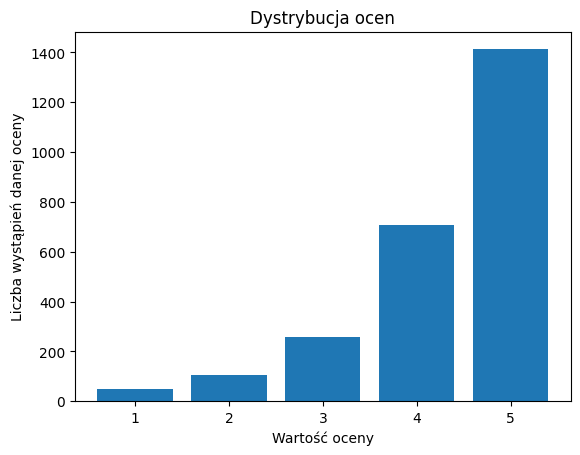

In [20]:
data_for_hist = df_5core.groupby('rating').count().loc[:,['user_id']].to_dict()['user_id']
import matplotlib.pyplot as plt
plt.bar(data_for_hist.keys(), data_for_hist.values())
plt.xlabel('Wartość oceny')
plt.ylabel('Liczba wystąpień danej oceny')
plt.title('Dystrybucja ocen')
plt.show()

In [7]:
# Chcemy grupowania: [4*train, test]
def mark_split(group):
    labels = ['train'] * len(group)
    labels[-1] = 'test' # dla kazdego uzytkownika, ostatnia recenzja bedzie testowa
    return labels

# grupujemy po user_id i potem wyciagamy ta kolumne dla kazdej z grup
df_5core['split'] = df_5core.groupby('user_id')['user_id'].transform(lambda x: mark_split(x))

In [8]:
df_5core

,user_id,parent_asin,rating,timestamp,split
2082,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B089R7S73D,3.0,1598559204579,train
2083,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B081D2R47W,3.0,1600086458543,train
2084,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B087ZQK2G8,3.0,1600100960642,train
2085,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B08BF4BKKM,4.0,1601079378337,train
2086,AE23ZBUF2YVBQPH2NN6F5XSA3QYQ,B0841WQNNZ,5.0,1604545336317,train
...,...,...,...,...,...
2169,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B089NJG212,5.0,1622106760041,train
2170,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B08SBV6Z57,5.0,1626763076907,train
2171,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B083PXJBVY,3.0,1631810149258,train
2172,AHYOSWORVZFXM5QMRIAW3JTTFFIQ,B09NFQ69KT,4.0,1646296769120,train


In [9]:
# uzywamy set-u, zeby pobierac z niego wartosci O(1)
train_keys = set(zip(df_5core[df_5core['split']=='train']['user_id'], df_5core[df_5core['split']=='train']['parent_asin']))
test_keys = set(zip(df_5core[df_5core['split']=='test']['user_id'], df_5core[df_5core['split']=='test']['parent_asin']))
valid_products = set(df_5core['parent_asin'].unique())

print(f"Keys for split ready: {len(train_keys)} train interactions, {len(test_keys)} test interactions. All of them: {len(train_keys)+len(test_keys)}")

Keys for split ready: 2282 train interactions, 253 test interactions. All of them: 2535


In [10]:
def clean_image_list_reviews(img_list):
    if isinstance(img_list, list) and len(img_list) > 0:
        return "|".join([dic.get('large_image_url', '') for dic in img_list if 'large_image_url' in dic]) # if sprawdza klucze
    return ""

def clean_image_list_products(img_list):
    if isinstance(img_list, list) and len(img_list) > 0:
        return "|".join([dic.get('large', '') for dic in img_list if 'large' in dic])
    return ""

def clean_list_of_texts(texts, delimiter = '|'):
  if isinstance(texts, list) and len(texts)>0:
    return delimiter.join(texts)
  return ""

def clean_text_from_unnecessary_characters(text):
  if isinstance(text, str):
    return text.replace('\n', ' ').replace('\r', '').replace('<br/>',' ')
  return ""

In [11]:
processed_pairs = set() # w pelnych recencjach czesto parent_asin,product_id sie powtarzaja w zaleznosci od rodzajow produktu(ten sam parent_asin ale rozne asin - czyli inny wariant np. kolorystyczny)
# dlatego bedziemy potrzebowac usunac powtarzajace sie pary

with open(files_config['out_train'], 'w', newline='', encoding='utf-8') as f_train, open(files_config['out_test'], 'w', newline='', encoding='utf-8') as f_test, open(files_config['full_reviews'], 'r', encoding='utf-8') as f_in:
    headers = ['user_id','parent_asin','timestamp', 'rating','title','text','images','helpful_vote','verified_purchase']
    #          str, str, int ( unix time), float( from 1.0-5.0) , str, str, list, int, bool
    writer_train = csv.DictWriter(f_train, fieldnames=headers)
    writer_test = csv.DictWriter(f_test, fieldnames=headers)
    writer_train.writeheader()
    writer_test.writeheader()

    count = 0
    saved_train = 0
    saved_test = 0

    for line in f_in:
        try:
            data = json.loads(line)
            u_id = data.get('user_id', data.get('user_id'))
            p_id = data.get('parent_asin', data.get('parent_asin'))
            pair = (u_id, p_id)
            if pair in processed_pairs:
                continue

            target_writer = None
            if pair in train_keys:
                target_writer = writer_train
                saved_train += 1
            elif pair in test_keys:
                target_writer = writer_test
                saved_test += 1

            if target_writer:

                row = {
                    'user_id': u_id,
                    'parent_asin': p_id,
                    'timestamp': data.get('timestamp'),
                    'rating': data.get('rating'),
                    'title': clean_text_from_unnecessary_characters(data.get('title',' ')),
                    'text': clean_text_from_unnecessary_characters(data.get('text',' ')),
                    'images': clean_image_list_reviews(data.get('images', [])),
                    'helpful_vote': data.get('helpful_vote'),
                    'verified_purchase': data.get('verified_purchase')
                }
                target_writer.writerow(row)
                processed_pairs.add(pair)

            count += 1
            if count % 100000 == 0:
                print(f"   Processed {count} raw reviews...")

        except json.JSONDecodeError:
            continue

print(f"Done. Saved {saved_train} training reviews and {saved_test} test reviews.")


   Processed 100000 raw reviews...
   Processed 200000 raw reviews...
   Processed 300000 raw reviews...
   Processed 400000 raw reviews...
   Processed 500000 raw reviews...
   Processed 600000 raw reviews...
   Processed 700000 raw reviews...
Done. Saved 2282 training reviews and 253 test reviews.


Można zauważyć, że niektóre pola test, title już w wygenerowanym pliku csv są w "" a niektóre nie są. Jest to związane z domyślnym formatowaniem typu csv, ponieważ, gdy CSV writer widzi, że np. pole text posiada przecinki, które w typowym pliku csv są znakiem odzdzielenia wartości do nastepnej kolumny, musi wstawić cały tekst do znaków "", żeby móc potem poprawnie podzielić wiersz na kolumny.

In [12]:
with open(files_config['out_prod'], 'w', newline='', encoding='utf-8') as f_prod, open(files_config['metadata'], 'r', encoding='utf-8') as f_in:

    headers = ['parent_asin', 'title', 'average_rating', 'rating_number', 'features', 'description','store', 'price','images']
    # str, str, float, int, list ( bullet point format), list, str, float, list
    writer = csv.DictWriter(f_prod, fieldnames=headers)
    writer.writeheader()

    count = 0
    saved_meta = 0

    for line in f_in:
        try:
            data = json.loads(line)
            p_id = data.get('parent_asin')

            if p_id in valid_products:
                row = {
                    'parent_asin': p_id,
                    'title': data.get('title', ''),
                    'average_rating': data.get('average_rating'),
                    'rating_number': data.get('rating_number'),
                    'features': clean_text_from_unnecessary_characters(clean_list_of_texts(data.get('features', []))),
                    'description': clean_text_from_unnecessary_characters(clean_list_of_texts(data.get('description', []))),
                    'store': data.get('store', ''),
                    'price': data.get('price', ''),
                    'images': clean_image_list_products(data.get('images', [])),
                }
                writer.writerow(row)
                saved_meta += 1

            count += 1
            if count % 50000 == 0:
                print(f"   Processed {count} product metadata lines...")

        except json.JSONDecodeError:
            continue

print(f"   Done. Saved {saved_meta} products.")

   Processed 50000 product metadata lines...
   Processed 100000 product metadata lines...
   Done. Saved 356 products.


5_core_reviews nie trzeba w ogóle czyścić:
user_id	[string]parent_asin[string]	rating[float]	timestamp[int - unix time].

W pliku podstawowym Beauty należy pamiętać, że 0.8 cen i 0.1 nazw sklepów to sa brakujące wartości. Więc one na pewno nie moga byc wymagane w bazie.

Należy pamiętać, że utworzone pliki CSV to są pliki tekstowe, więc jeżeli będziemy cokolwiek z nich pobierać i do nich zapisywać, to tam każde pole domyślnie jest traktowane jako string. Należy to mieć na uwadze przy imporcie do bazy i eksporcie do plików csv.